#### NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 8 - Mini projects (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. Here, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

In [1]:
import sys
sys.path.append('./../')
!{sys.executable} -m pip install gdown h5py

You should consider upgrading via the '/home/vvoigt/Documents/NX/NX-414-Project/venv/bin/python -m pip install --upgrade pip' command.


In [2]:
import utils
import matplotlib.pyplot as plt
import numpy as np
import gdown
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
gdown.download(url, output, quiet=False, fuzzy=True)


Downloading...
From (original): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS
From (redirected): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS&confirm=t&uuid=cedfb69a-81c0-42af-8536-ab90c98ccfd1
To: /home/vvoigt/IT_data.h5
100%|████████████████████████████████████████████████████████████████████████████████████████████| 384M/384M [00:02<00:00, 171MB/s]


'IT_data.h5'

### Load the data

In [3]:
###copy pasted from utils, since import did somehow not work...
import h5py
import os

import matplotlib.pyplot as plt
import numpy as np
def load_it_data(path_to_data):
    """ Load IT data

    Args:
        path_to_data (str): Path to the data

    Returns:
        np.array (x6): Stimulus train/val/test; objects list train/val/test; spikes train/val
    """

    datafile = h5py.File(os.path.join(path_to_data,'IT_data.h5'), 'r')

    stimulus_train = datafile['stimulus_train'][()]
    spikes_train = datafile['spikes_train'][()]
    objects_train = datafile['object_train'][()]
    
    stimulus_val = datafile['stimulus_val'][()]
    spikes_val = datafile['spikes_val'][()]
    objects_val = datafile['object_val'][()]
    
    stimulus_test = datafile['stimulus_test'][()]
    objects_test = datafile['object_test'][()]

    ### Decode back object type to latin
    objects_train = [obj_tmp.decode("latin-1") for obj_tmp in objects_train]
    objects_val = [obj_tmp.decode("latin-1") for obj_tmp in objects_val]
    objects_test = [obj_tmp.decode("latin-1") for obj_tmp in objects_test]

    return stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val


def visualize_img(stimulus,objects,stim_idx):
    """Visualize image given the stimulus and corresponding index and the object name.

    Args:
        stimulus (array of float): Stimulus containing all the images
        objects (list of str): Object list containing all the names
        stim_idx (int): Index of the stimulus to plot
    """    
    normalize_mean=[0.485, 0.456, 0.406]
    normalize_std=[0.229, 0.224, 0.225]

    img_tmp = np.transpose(stimulus[stim_idx],[1,2,0])

    ### Go back from normalization
    img_tmp = (img_tmp*normalize_std + normalize_mean) * 255

    plt.figure()
    plt.imshow(img_tmp.astype(np.uint8),cmap='gray')
    plt.title(str(objects[stim_idx]))
    plt.show()
    return

In [4]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [5]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


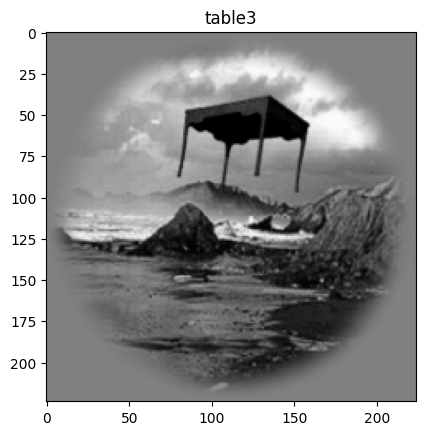

In [6]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

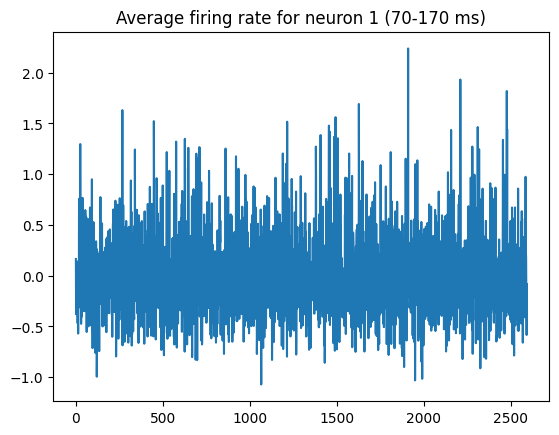

In [7]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

# Challenge: Develop the most accurate model for predicting IT neural activity.

Throughout the mini-projects, you have acquired knowledge on predicting neural activity through both task-driven and data-driven approaches. You are now free to explore both approaches to create the most effective model for predicting neural activity. Here are some suggestions to help guide your exploration:
- Optimize your current models by adjusting hyperparameters and implementing different regularizations.
- Utilize different pretrained models.
- Employ a pretrained neural network and finetune it for predicting the neural activity.
- Train a neural network for object recognition while simultaneously predicting neural activity.
- ...

Please note that all models will be tested using the same type of linear regression.

### EVALUATION

You have until midnight of 07/05/25 to submit your mini-projects. Please upload a .zip file on Moodle containing your code and, specifically, the following:

- A one-page report (Report.pdf) detailing your investigation, including figures and model comparisons.
- A script (test.py) or notebook (test.ipynb) in which you show an example of your best model's usage. Please include instructions on loading the model and making neural predictions on the validation set. If necessary, include the checkpoint of your model in the .zip file.

Best of luck!

In [8]:
### Here your code

### Use VGG16 for object recognition while simultaneously predicting neural activity.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader, TensorDataset

# Define the multi-task model
class VGG16_MultiTask(nn.Module):
    def __init__(self, pretrained_model, num_classes, num_neurons):
        super(VGG16_MultiTask, self).__init__()
        self.features = pretrained_model.features
        
        # Shared fully connected layer before branching
        self.shared_fc = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        # Task-specific heads
        self.classification_head = nn.Linear(4096, num_classes)  # for object recognition
        self.neural_head = nn.Linear(4096, num_neurons)           # for predicting neural spikes

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.shared_fc(x)
        
        class_output = self.classification_head(x)
        neural_output = self.neural_head(x)
        
        return class_output, neural_output

# Function to create dataloaders
def create_multitask_dataloader(stimulus, objects, spikes, batch_size):
    dataset = TensorDataset(stimulus, objects, spikes)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

# Training function
def train_multitask_model(
    stimulus_train, objects_train, spikes_train,
    stimulus_val, objects_val, spikes_val,
    num_classes, num_neurons,
    learning_rate=1e-4,
    batch_size_train=64,
    batch_size_val=32,
    num_epochs=10,
    loss_weight_spikes=1.0
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Initialize the model
    pretrained_vgg = models.vgg16(pretrained=True)
    model = VGG16_MultiTask(pretrained_vgg, num_classes, num_neurons)
    model.to(device)

    # Prepare the data
    stimulus_train_tensor = torch.tensor(stimulus_train, dtype=torch.float32)
    objects_train_tensor = torch.tensor(objects_train, dtype=torch.long)
    spikes_train_tensor = torch.tensor(spikes_train, dtype=torch.float32)
    
    stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
    objects_val_tensor = torch.tensor(objects_val, dtype=torch.long)
    spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)

    train_loader = create_multitask_dataloader(stimulus_train_tensor, objects_train_tensor, spikes_train_tensor, batch_size_train)
    val_loader = create_multitask_dataloader(stimulus_val_tensor, objects_val_tensor, spikes_val_tensor, batch_size_val)

    # Losses
    criterion_classification = nn.CrossEntropyLoss()
    criterion_neural = nn.MSELoss()

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_input, batch_objects, batch_spikes in train_loader:
            batch_input, batch_objects, batch_spikes = batch_input.to(device), batch_objects.to(device), batch_spikes.to(device)

            optimizer.zero_grad()

            # Forward
            outputs_class, outputs_neural = model(batch_input)

            # Losses
            loss_class = criterion_classification(outputs_class, batch_objects)
            loss_neural = criterion_neural(outputs_neural, batch_spikes)

            # Total loss (you can adjust weighting)
            loss = loss_class + loss_weight_spikes * loss_neural

            # Backprop
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Combined Loss: {avg_loss:.4f}")

    return model


In [10]:
# One-hot encode objects so that string becomes int
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
objects_train_encoded = label_encoder.fit_transform(objects_train)
objects_val_encoded = label_encoder.transform(objects_val)

In [11]:
model_multitask = train_multitask_model(
    stimulus_train, objects_train_encoded, spikes_train,
    stimulus_val, objects_val_encoded, spikes_val,
    num_classes=len(label_encoder.classes_),
    num_neurons=spikes_train.shape[1], 
    learning_rate=1e-4,
    batch_size_train=128,
    batch_size_val=64,
    num_epochs=20,
    loss_weight_spikes=0.5
)

/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vvoigt/Documents/NX/NX-414-Project/venv/lib64/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20], Combined Loss: 2.8036
Epoch [2/20], Combined Loss: 0.8770
Epoch [3/20], Combined Loss: 0.4428
Epoch [4/20], Combined Loss: 0.2520
Epoch [5/20], Combined Loss: 0.1706
Epoch [6/20], Combined Loss: 0.1323
Epoch [7/20], Combined Loss: 0.1103
Epoch [8/20], Combined Loss: 0.0957
Epoch [9/20], Combined Loss: 0.0861
Epoch [10/20], Combined Loss: 0.0787
Epoch [11/20], Combined Loss: 0.0726
Epoch [12/20], Combined Loss: 0.0671
Epoch [13/20], Combined Loss: 0.0626
Epoch [14/20], Combined Loss: 0.0588
Epoch [15/20], Combined Loss: 0.0551
Epoch [16/20], Combined Loss: 0.0521
Epoch [17/20], Combined Loss: 0.0493
Epoch [18/20], Combined Loss: 0.0466
Epoch [19/20], Combined Loss: 0.0442
Epoch [20/20], Combined Loss: 0.0423


In [12]:
import torch
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score, accuracy_score

def evaluate_multitask_model(model, stimulus_val, objects_val_encoded, spikes_val, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model.to(device)
    
    stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32).to(device)
    spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32).to(device)
    objects_val_tensor = torch.tensor(objects_val_encoded, dtype=torch.long).to(device)

    with torch.no_grad():
        outputs_object, outputs_spike = model(stimulus_val_tensor)

    # Move outputs to CPU
    outputs_spike = outputs_spike.cpu().numpy()
    spikes_val = spikes_val_tensor.cpu().numpy()

    outputs_object = outputs_object.cpu().numpy()
    objects_val = objects_val_tensor.cpu().numpy()

    ### Evaluation for spike prediction
    n_neurons = spikes_val.shape[1]
    pearson_scores = []
    explained_var_scores = []

    for neuron_idx in range(n_neurons):
        pred = outputs_spike[:, neuron_idx]
        true = spikes_val[:, neuron_idx]

        # Pearson correlation
        if np.std(pred) > 0 and np.std(true) > 0:  # To avoid division by zero
            r, _ = pearsonr(pred, true)
        else:
            r = np.nan
        pearson_scores.append(r)

        # Explained variance
        ev = explained_variance_score(true, pred)
        explained_var_scores.append(ev)

    mean_pearson = np.nanmean(pearson_scores)
    mean_explained_variance = np.mean(explained_var_scores)

    ### Evaluation for object recognition
    predicted_labels = np.argmax(outputs_object, axis=1)
    classification_accuracy = accuracy_score(objects_val, predicted_labels)

    print("Evaluation Results:")
    print(f"Spike prediction - Mean Pearson correlation: {mean_pearson:.4f}")
    print(f"Spike prediction - Mean Explained Variance: {mean_explained_variance:.4f}")
    print(f"Object recognition - Accuracy: {classification_accuracy * 100:.2f}%")

    return {
        'mean_pearson': mean_pearson,
        'mean_explained_variance': mean_explained_variance,
        'classification_accuracy': classification_accuracy
    }


In [13]:
metrics = evaluate_multitask_model(model_multitask, stimulus_val, objects_val_encoded, spikes_val)

Evaluation Results:
Spike prediction - Mean Pearson correlation: 0.5529
Spike prediction - Mean Explained Variance: 0.2877
Object recognition - Accuracy: 86.81%


trying for image.

In [20]:
from sklearn.preprocessing import LabelEncoder
import torch

# Step 1: Encode string labels
label_encoder = LabelEncoder()
objects_val_encoded = label_encoder.fit_transform(objects_val)

# Step 2: Convert to tensor
objects_val_tensor = torch.tensor(objects_val_encoded, dtype=torch.long)


batch_size_val=32
stimulus_val_tensor = torch.tensor(stimulus_val, dtype=torch.float32)
#objects_val_tensor = torch.tensor(objects_val, dtype=torch.long)
spikes_val_tensor = torch.tensor(spikes_val, dtype=torch.float32)
val_loader = create_multitask_dataloader(stimulus_val_tensor, objects_val_tensor, spikes_val_tensor, batch_size_val)


In [26]:
for images, object_labels, spike_targets in val_loader:
    print("Image batch shape:", images.shape)
    break


Image batch shape: torch.Size([32, 3, 224, 224])


In [32]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_multitask.to(device)


# Assume your model is already trained
model_multitask.eval()

# Define hooks to capture intermediate layer outputs
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks for desired layers
model_multitask.features[0].register_forward_hook(get_activation('conv1_1'))
model_multitask.features[5].register_forward_hook(get_activation('conv2_2'))
model_multitask.features[10].register_forward_hook(get_activation('conv3_3'))
model_multitask.features[17].register_forward_hook(get_activation('conv4_3'))
model_multitask.features[24].register_forward_hook(get_activation('conv5_3'))

# Example with validation data
for images, object_labels, spike_targets in val_loader:
    with torch.no_grad():
        images = images.to(device)  # Move images to GPU if model is on GPU
        outputs = model_multitask(images)


        conv1_1_output = activations['conv1_1']
        conv2_2_output = activations['conv2_2']
        conv3_3_output = activations['conv3_3']
        conv4_3_output = activations['conv4_3']
        conv5_3_output = activations['conv5_3']
        
    print(conv1_1_output.shape)



torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])
torch.Size([32, 64, 224, 224])


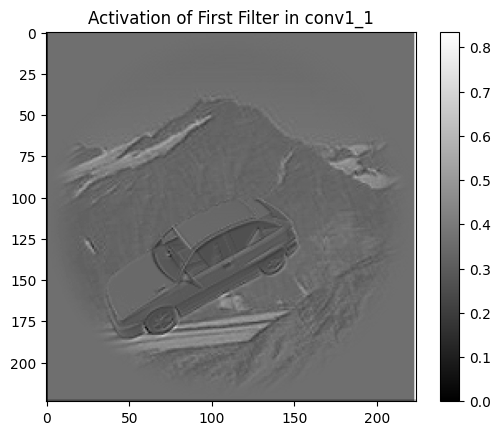

In [31]:
import matplotlib.pyplot as plt

# Example: Visualize the first channel of conv1_1 output (for simplicity, let's show one filter/channel)
conv1_1_output = activations['conv1_1']
# Choose the first filter (channel) from the output
filter_img = conv1_1_output[0, 0].cpu().numpy()  # First image in batch, first filter

plt.imshow(filter_img, cmap='gray')
plt.title('Activation of First Filter in conv1_1')
plt.colorbar()
plt.show()


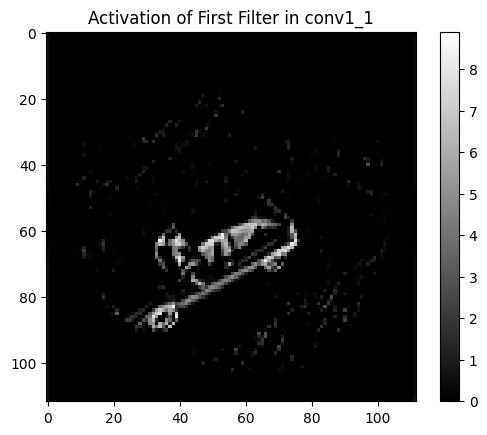

In [30]:
import matplotlib.pyplot as plt

# Example: Visualize the first channel of conv1_1 output (for simplicity, let's show one filter/channel)
conv1_1_output = activations['conv2_2']
# Choose the first filter (channel) from the output
filter_img = conv1_1_output[0, 0].cpu().numpy()  # First image in batch, first filter

plt.imshow(filter_img, cmap='gray')
plt.title('Activation of First Filter in conv1_1')
plt.colorbar()
plt.show()


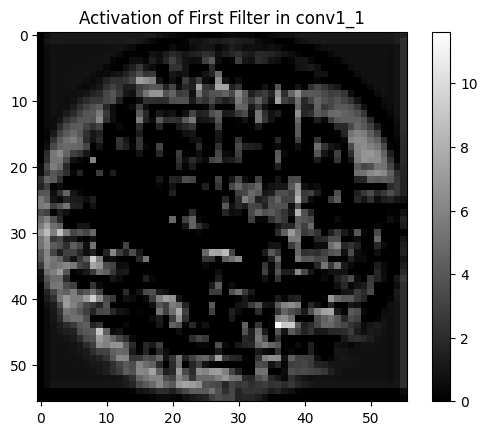

In [33]:
import matplotlib.pyplot as plt

# Example: Visualize the first channel of conv1_1 output (for simplicity, let's show one filter/channel)
conv1_1_output = activations['conv3_3']
# Choose the first filter (channel) from the output
filter_img = conv1_1_output[0, 0].cpu().numpy()  # First image in batch, first filter

plt.imshow(filter_img, cmap='gray')
plt.title('Activation of First Filter in conv1_1')
plt.colorbar()
plt.show()


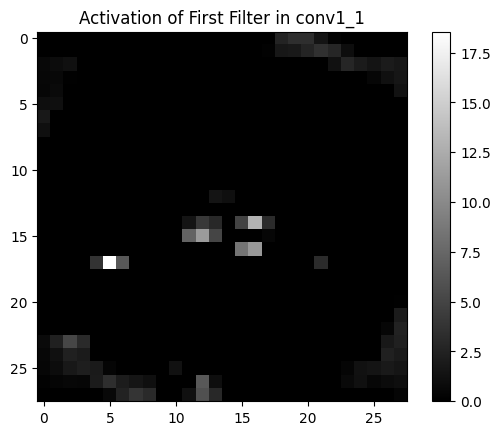

In [34]:
import matplotlib.pyplot as plt

# Example: Visualize the first channel of conv1_1 output (for simplicity, let's show one filter/channel)
conv1_1_output = activations['conv4_3']
# Choose the first filter (channel) from the output
filter_img = conv1_1_output[0, 0].cpu().numpy()  # First image in batch, first filter

plt.imshow(filter_img, cmap='gray')
plt.title('Activation of First Filter in conv1_1')
plt.colorbar()
plt.show()


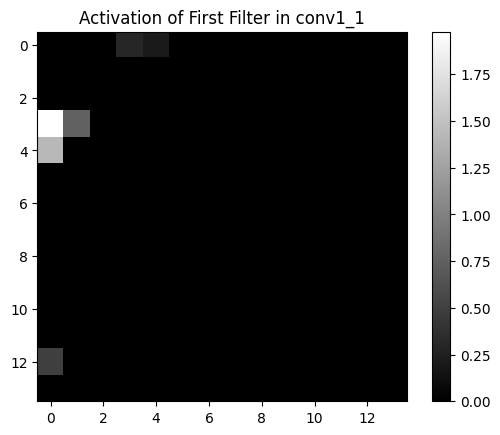

In [35]:
import matplotlib.pyplot as plt

# Example: Visualize the first channel of conv1_1 output (for simplicity, let's show one filter/channel)
conv1_1_output = activations['conv5_3']
# Choose the first filter (channel) from the output
filter_img = conv1_1_output[0, 0].cpu().numpy()  # First image in batch, first filter

plt.imshow(filter_img, cmap='gray')
plt.title('Activation of First Filter in conv1_1')
plt.colorbar()
plt.show()
